Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile
import os

In [7]:
zip_path = "/content/drive/MyDrive/Deeplearning"

In [8]:
extract_path = "/content/fake_news_dataset"

Extract Dataset from ZIP

In [9]:
import os

folder = '/content/drive/MyDrive/Deeplearning'


extract_path = "/content/fake_news_dataset"
zip_files = [f for f in os.listdir(folder) if f.endswith('.zip') and 'Fake News' in f]

if zip_files:
    correct_file = zip_files[0]
    zip_path = os.path.join(folder, correct_file)
    print(" Found file:", correct_file)
    print("Full path:", zip_path)
    import zipfile
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extraction Successful!")
else:
    print("No matching zip file found")

 Found file: 10.True vs. Fake News Dataset-20260509T075710Z-3-001.zip
Full path: /content/drive/MyDrive/Deeplearning/10.True vs. Fake News Dataset-20260509T075710Z-3-001.zip
 Extraction Successful!


Verify Extracted Files

In [10]:
print(os.listdir(extract_path))

['10.True vs. Fake News Dataset']


In [11]:
dataset_folder = "/content/fake_news_dataset/10.True vs. Fake News Dataset"

print(os.listdir(dataset_folder))

['truevsfakenews.csv', '10.Description True Vs. Fake News Dataset.txt']


Import Pandas

In [12]:
import pandas as pd

Load the Dataset

In [13]:
df = pd.read_csv(dataset_folder + "/truevsfakenews.csv")

Preview the Dataset

In [14]:
df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


Check Dataset Shape

In [15]:
print(df.shape)

(20000, 2)


Check Class Distribution

In [16]:
print(df['label'].value_counts())

label
true    10000
fake    10000
Name: count, dtype: int64


Check for Missing Values

In [17]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


Dataset Info

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


 Import NLP Libraries

In [19]:
import re
import nltk


Download NLTK Resources

In [20]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Import Stopwords and Lemmatizer

In [21]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

Initialize Stopwords and Lemmatizer

In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Define Text Cleaning Function

In [23]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back
    text = ' '.join(words)

    return text

Apply Text Cleaning

In [24]:
df['clean_text'] = df['text'].apply(clean_text)

Preview Cleaned Text

In [25]:
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood u medical service p...,true


Encode Labels

In [26]:
df['label'] = df['label'].map({
    'fake': 0,
    'true': 1
})

 Verify Label Encoding

In [27]:
print(df['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


Import Visualization Libraries

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


 Plot Class Distribution

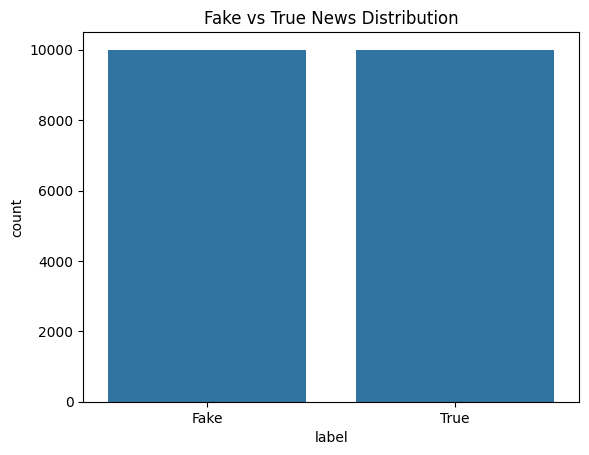

In [29]:
sns.countplot(x='label', data=df)

plt.title("Fake vs True News Distribution")

plt.xticks([0,1], ['Fake', 'True'])

plt.show()

Install WordCloud

In [30]:
!pip install wordcloud

Import WordCloud

In [31]:
from wordcloud import WordCloud

Fake News Word Cloud

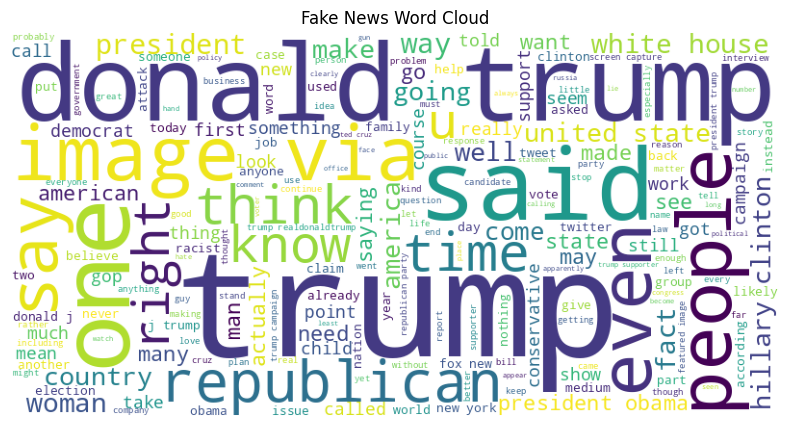

In [32]:
fake_words = ' '.join(
    df[df['label'] == 0]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Fake News Word Cloud")

plt.show()

True News Word Cloud

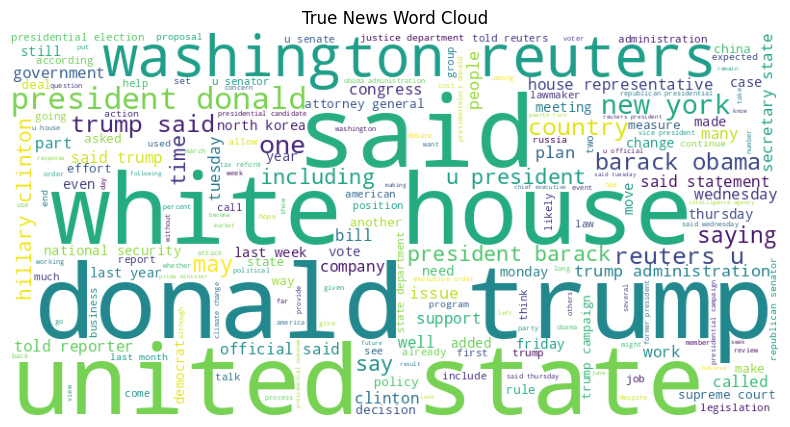

In [33]:
true_words = ' '.join(
    df[df['label'] == 1]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("True News Word Cloud")

plt.show()

Import Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

Separate Features and Labels

In [35]:
X = df['clean_text']
y = df['label']

Split Dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Verify Split Sizes

In [37]:
print("Training Data:", len(X_train))
print("Testing Data :", len(X_test))

Training Data: 16000
Testing Data : 4000


Import Tokenizer and Padding

In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

 Initialize Tokenizer

In [39]:
tokenizer = Tokenizer(num_words=10000)

Fit Tokenizer on Training Data

In [40]:
tokenizer.fit_on_texts(X_train)

Convert Text to Sequences

In [41]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Preview Tokenized Output

In [42]:
print(X_train.iloc[0])
print(X_train_seq[0])

reuters following people mentioned contender senior role u presidentelect donald trump assembles administration taking office jan according reuters source medium report trump already named number people top job administration sonny perdue former georgia governor elsa murano undersecretary agriculture food safety president george w bush former president texas university chuck conner former acting secretary u agriculture department current head national council farmer cooperative abel maldonado former lieutenant governor california coowner runway vineyard tim huelskamp republican u representative kansa sid miller texas agriculture commissioner navy admiral mike rogers director national security agency ronald burgess retired u army lieutenant general former defense intelligence agency chief robert cardillo director national geospatialintelligence agency pete hoekstra republican former u representative michigan john allison former chief executive officer regional bank bbt corp former head 

Analyze Sequence Lengths

In [43]:
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Maximum Length:", max(sequence_lengths))
print("Average Length:", int(sum(sequence_lengths)/len(sequence_lengths)))

Maximum Length: 3931
Average Length: 222


 Determine Padding Length Using 95th Percentile

In [44]:
import numpy as np

max_len = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Length:", max_len)

95th Percentile Length: 470


 Apply Post-Padding to Sequences

In [45]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

Verify Padded Shapes

In [46]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

X_train_pad shape: (16000, 470)
X_test_pad shape : (4000, 470)


Import Keras Model Components

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

Set Vocabulary and Embedding Size

In [48]:
vocab_size = 10000
embedding_dim = 128

 Build Simple RNN Model

In [49]:
model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Simple RNN Model

In [50]:
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Print Simple RNN Summary

In [51]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

 Train Simple RNN Model

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [55]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.5002 - loss: 0.7305 - val_accuracy: 0.5444 - val_loss: 0.6871
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5300 - loss: 0.7073 - val_accuracy: 0.5475 - val_loss: 0.6852
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5510 - loss: 0.6865 - val_accuracy: 0.5462 - val_loss: 0.6882
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.5545 - loss: 0.6782 - val_accuracy: 0.5466 - val_loss: 0.6804
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.5551 - loss: 0.6746 - val_accuracy: 0.5478 - val_loss: 0.6842
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5459 - loss: 0.6730 - val_accuracy: 0.5447 - val_loss: 0.6801
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5626 - loss: 0.6671 - val_accuracy: 0.5291 - val_loss: 0.6781
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.5686 - loss: 0.6626 - 

Evaluate Simple RNN Model

In [56]:
rnn_loss, rnn_accuracy = model_rnn.evaluate(X_test_pad, y_test)

print("RNN Test Accuracy:", rnn_accuracy)
print("RNN Test Loss:", rnn_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5595 - loss: 0.6700
RNN Test Accuracy: 0.559499979019165
RNN Test Loss: 0.6700260043144226


Plot Simple RNN Training Curves

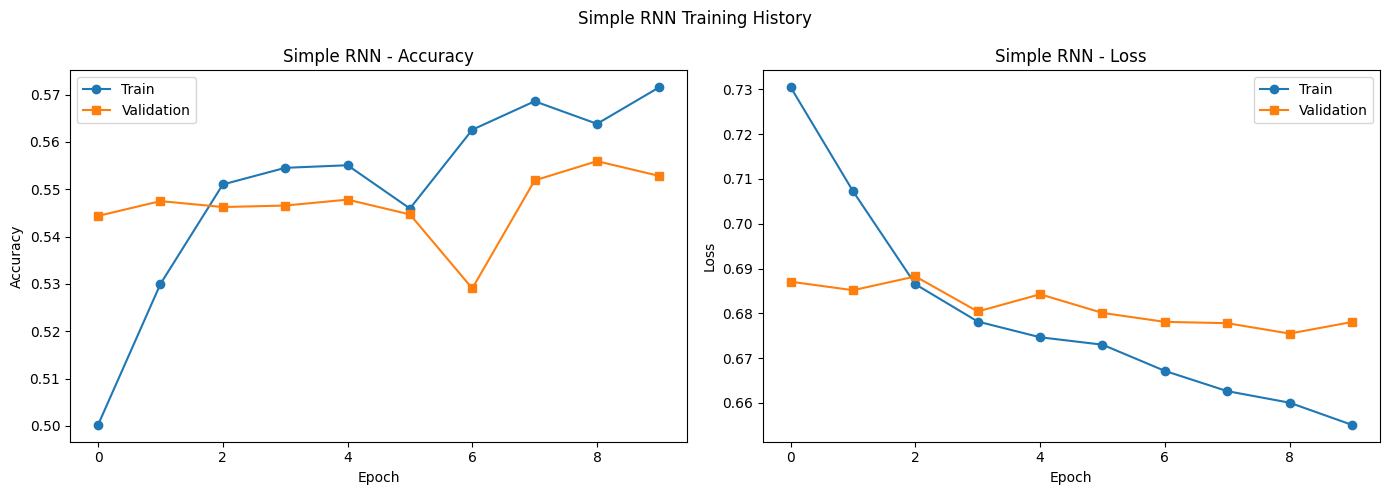

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['accuracy'], label='Train', marker='o')
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Simple RNN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rnn.history['loss'], label='Train', marker='o')
axes[1].plot(history_rnn.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Simple RNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Simple RNN Training History')
plt.tight_layout()
plt.show()

Build LSTM Model with Post-Padding

In [58]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

Compile LSTM Post-Padding Model

In [59]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Train LSTM Post-Padding Model

In [63]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.5272 - loss: 0.6830 - val_accuracy: 0.5259 - val_loss: 0.6744
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5336 - loss: 0.6675 - val_accuracy: 0.5269 - val_loss: 0.6740
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8112 - loss: 0.3672 - val_accuracy: 0.9741 - val_loss: 0.0951
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9765 - loss: 0.1013 - val_accuracy: 0.9641 - val_loss: 0.1362
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9777 - loss: 0.1070 - val_accuracy: 0.9762 - val_loss: 0.0896
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9898 - loss: 0.0575 - val_accuracy: 0.9725 - val_loss: 0.1029
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9941 - loss: 0.0382 - val_accuracy: 0.9775 - val_loss: 0.0927
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9970 - loss: 0.0231 - val_acc

Evaluate LSTM Post-Padding Model

In [64]:
lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9780 - loss: 0.0906
LSTM Test Accuracy: 0.9779999852180481
LSTM Test Loss: 0.09063971042633057


Plot LSTM Post-Padding Training Curves

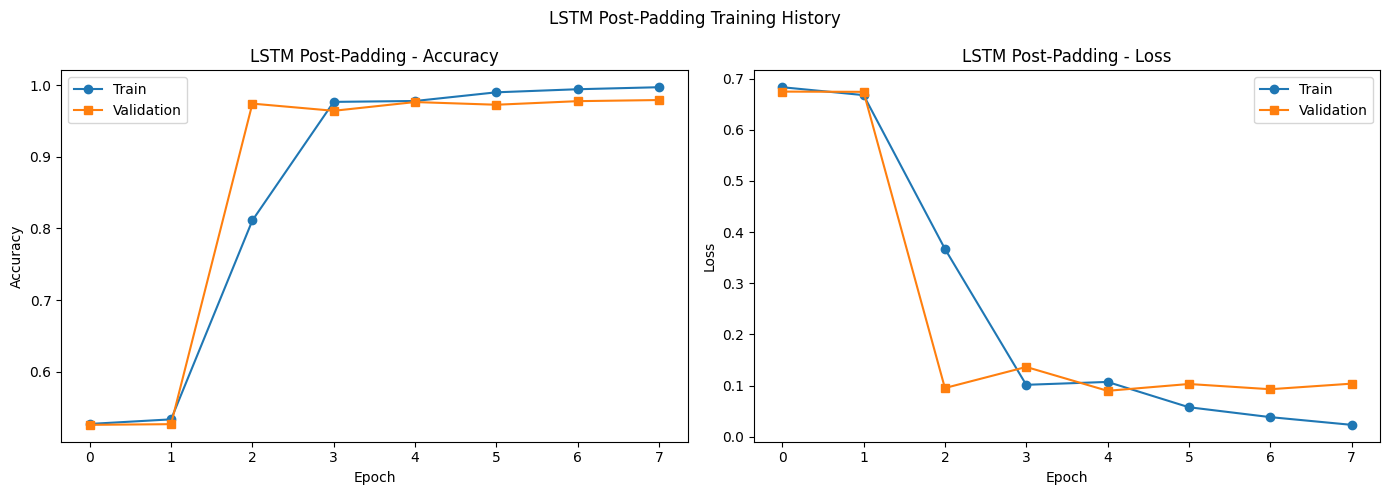

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['accuracy'], label='Train', marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('LSTM Post-Padding - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train', marker='o')
axes[1].plot(history_lstm.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('LSTM Post-Padding - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('LSTM Post-Padding Training History')
plt.tight_layout()
plt.show()

Apply Pre-Padding to Sequences

In [66]:
X_train_pad_pre = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

X_test_pad_pre = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

Build LSTM Model with Pre-Padding

In [67]:
model_lstm_pre = Sequential()

model_lstm_pre.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
)

model_lstm_pre.add(LSTM(64))

model_lstm_pre.add(Dropout(0.5))

model_lstm_pre.add(Dense(1, activation='sigmoid'))

Compile LSTM Pre-Padding Model

In [68]:
model_lstm_pre.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Train LSTM Pre-Padding Model

In [69]:
history_lstm_pre = model_lstm_pre.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9638 - loss: 0.1128 - val_accuracy: 0.9847 - val_loss: 0.0480
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9899 - loss: 0.0348 - val_accuracy: 0.9822 - val_loss: 0.0563
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9972 - loss: 0.0120 - val_accuracy: 0.9844 - val_loss: 0.0583
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9983 - loss: 0.0067 - val_accuracy: 0.9856 - val_loss: 0.0767


Evaluate LSTM Pre-Padding Model

In [70]:
lstm_pre_loss, lstm_pre_accuracy = model_lstm_pre.evaluate(
    X_test_pad_pre,
    y_test
)

print("Improved LSTM Test Accuracy:", lstm_pre_accuracy)
print("Improved LSTM Test Loss:", lstm_pre_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9833 - loss: 0.0502
Improved LSTM Test Accuracy: 0.9832500219345093
Improved LSTM Test Loss: 0.05021842196583748


Summarize First Three Model Results

In [71]:
results = {
    "Simple RNN": rnn_accuracy,
    "LSTM Post Padding": lstm_accuracy,
    "Improved LSTM Pre Padding": lstm_pre_accuracy
}

results

{'Simple RNN': 0.559499979019165,
 'LSTM Post Padding': 0.9779999852180481,
 'Improved LSTM Pre Padding': 0.9832500219345093}

Generate Predictions from Best LSTM Model

In [72]:
y_pred_probs = model_lstm_pre.predict(X_test_pad_pre)

y_pred = (y_pred_probs > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Import Evaluation Metric Functions

In [73]:
from sklearn.metrics import confusion_matrix, classification_report

Print Full Classification Report

In [74]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Fake', 'True']
))

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      2055
        True       0.98      0.99      0.98      1945

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



 Plot Confusion Matrix

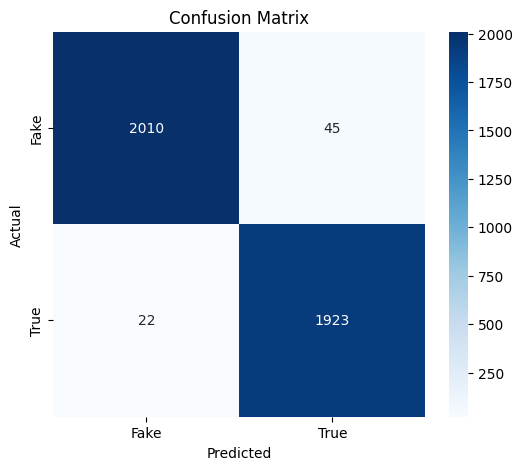

In [75]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Plot LSTM Pre-Padding Accuracy Curves

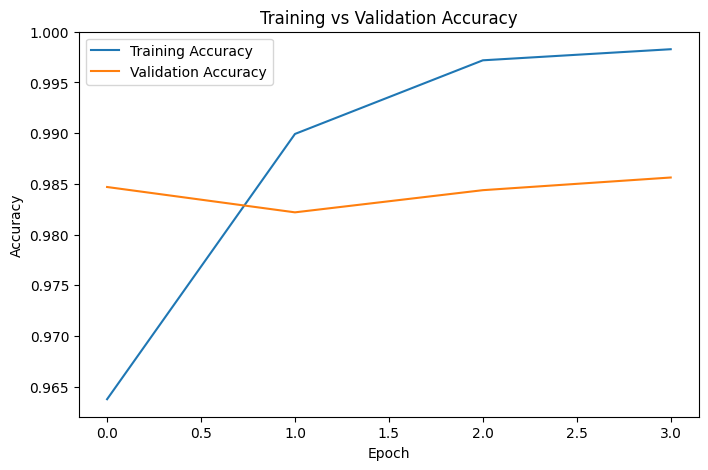

In [76]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm_pre.history['accuracy'], label='Training Accuracy')

plt.plot(history_lstm_pre.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

Plot LSTM Pre-Padding Loss Curves

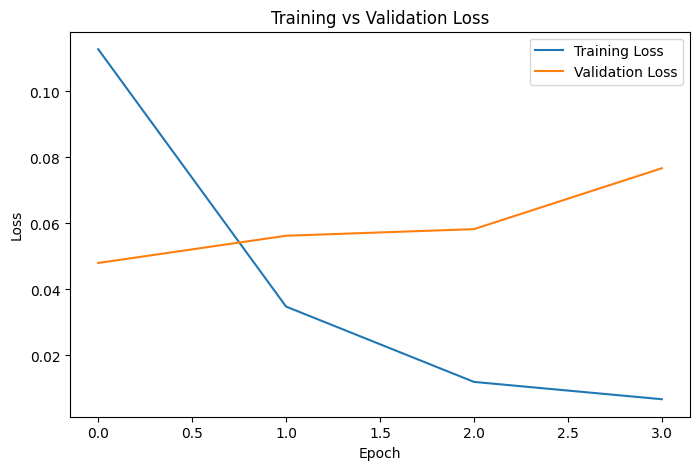

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm_pre.history['loss'], label='Training Loss')

plt.plot(history_lstm_pre.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

 Build Three-Model Comparison DataFrame

In [78]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM Post Padding',
        'Improved LSTM Pre Padding'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        lstm_pre_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Simple RNN,0.55950
1,LSTM Post Padding,0.97800
2,Improved LSTM Pre Padding,0.98325


Plot Three-Model Accuracy Bar Chart

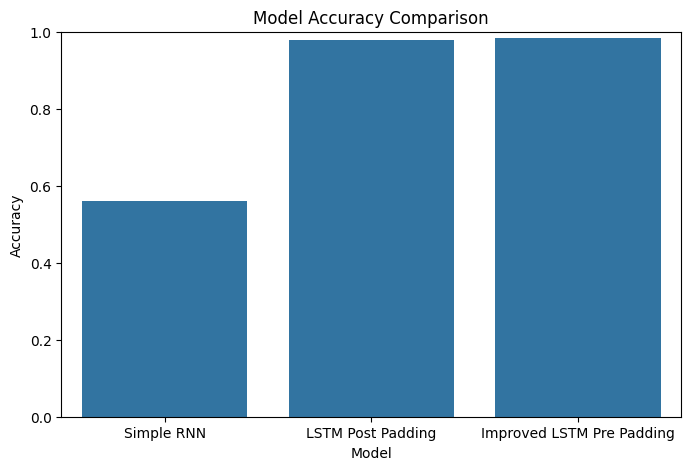

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

Install Gensim Library

In [80]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.1 MB/s eta 0:00:00


Import Gensim Downloader API

In [81]:
import gensim.downloader as api

Load Pretrained GloVe Word Embeddings

In [82]:
word2vec_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


Test GloVe Embedding Lookup

In [83]:
print(word2vec_model['news'])

[-0.20825   0.47786   0.52196   1.0587   -0.10045  -1.1269   -1.2581
 -0.11041  -0.074125 -0.77976  -0.37942  -0.2486   -0.39224   0.42972
  0.9806    0.12668  -1.3772   -0.22793  -0.18497   0.41014   0.96781
  0.8916    0.84685   0.57416   0.46455  -1.7287   -0.63918   0.56256
 -0.12651   0.49711   3.3326    0.034399  0.46149  -0.44826  -1.1945
 -0.47593  -0.31927  -0.6442    0.089735  0.073952  0.70755   0.52948
 -0.12034  -0.46779   0.24722   0.28045  -0.62632   1.4458    0.51045
  0.74156 ]


Retrieve Word Index and Set Embedding Dimension

In [86]:
word_index = tokenizer.word_index

embedding_dim = 50

Build GloVe Embedding Matrix

In [87]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 50)


Build LSTM Model with Pretrained GloVe Embeddings

In [88]:
model_w2v_lstm = Sequential()

model_w2v_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

model_w2v_lstm.add(LSTM(64))

model_w2v_lstm.add(Dropout(0.5))

model_w2v_lstm.add(Dense(1, activation='sigmoid'))

Compile GloVe LSTM Model

In [89]:
model_w2v_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

 Train GloVe LSTM Model

In [90]:
history_w2v_lstm = model_w2v_lstm.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9462 - loss: 0.1625 - val_accuracy: 0.9516 - val_loss: 0.1371
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9661 - loss: 0.1027 - val_accuracy: 0.9591 - val_loss: 0.0967
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9670 - loss: 0.0952 - val_accuracy: 0.9541 - val_loss: 0.1103


Evaluate GloVe LSTM Model

In [91]:
w2v_lstm_loss, w2v_lstm_accuracy = model_w2v_lstm.evaluate(
    X_test_pad_pre,
    y_test
)

print("Word2Vec + LSTM Test Accuracy:", w2v_lstm_accuracy)
print("Word2Vec + LSTM Test Loss:", w2v_lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9510 - loss: 0.1272
Word2Vec + LSTM Test Accuracy: 0.9509999752044678
Word2Vec + LSTM Test Loss: 0.12717822194099426


Plot GloVe LSTM Training Curves

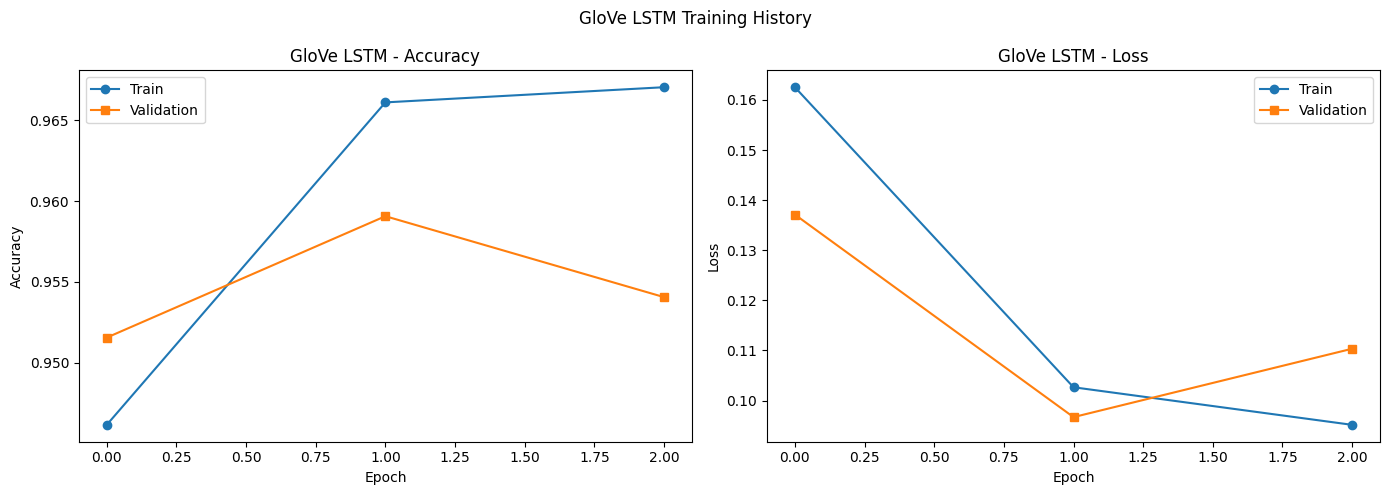

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v_lstm.history['accuracy'], label='Train', marker='o')
axes[0].plot(history_w2v_lstm.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('GloVe LSTM - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_w2v_lstm.history['loss'], label='Train', marker='o')
axes[1].plot(history_w2v_lstm.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('GloVe LSTM - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('GloVe LSTM Training History')
plt.tight_layout()
plt.show()

 Build Final Four-Model Comparison DataFrame

In [93]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM Post Padding',
        'Improved LSTM Pre Padding',
        'Word2Vec + LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        lstm_pre_accuracy,
        w2v_lstm_accuracy
    ],
    'Loss': [
        rnn_loss,
        lstm_loss,
        lstm_pre_loss,
        w2v_lstm_loss
    ]
})

comparison_df

,Model,Accuracy,Loss
0,Simple RNN,0.55950,0.670026
1,LSTM Post Padding,0.97800,0.090640
2,Improved LSTM Pre Padding,0.98325,0.050218
3,Word2Vec + LSTM,0.95100,0.127178


Plot All Models Validation Curves Together

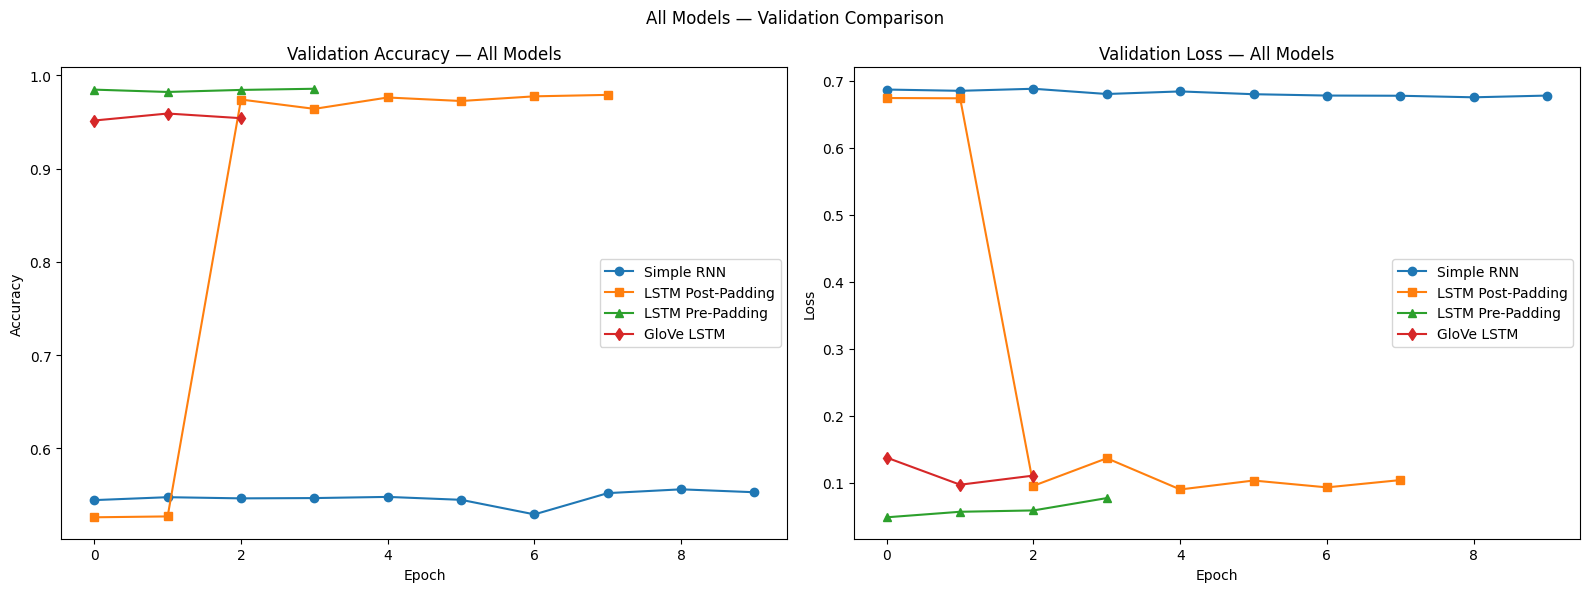

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_rnn.history['val_accuracy'], label='Simple RNN', marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM Post-Padding', marker='s')
axes[0].plot(history_lstm_pre.history['val_accuracy'], label='LSTM Pre-Padding', marker='^')
axes[0].plot(history_w2v_lstm.history['val_accuracy'], label='GloVe LSTM', marker='d')
axes[0].set_title('Validation Accuracy — All Models')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rnn.history['val_loss'], label='Simple RNN', marker='o')
axes[1].plot(history_lstm.history['val_loss'], label='LSTM Post-Padding', marker='s')
axes[1].plot(history_lstm_pre.history['val_loss'], label='LSTM Pre-Padding', marker='^')
axes[1].plot(history_w2v_lstm.history['val_loss'], label='GloVe LSTM', marker='d')
axes[1].set_title('Validation Loss — All Models')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('All Models — Validation Comparison')
plt.tight_layout()
plt.show()

 Generate Predictions for All Four Models

In [95]:

y_pred_rnn = (model_rnn.predict(X_test_pad) > 0.5).astype(int)
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int)
y_pred_lstm_pre = (model_lstm_pre.predict(X_test_pad_pre) > 0.5).astype(int)
y_pred_w2v = (model_w2v_lstm.predict(X_test_pad_pre) > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


confusion matrices for all 4 models

In [96]:
# Generate predictions for all models
y_pred_rnn = (model_rnn.predict(X_test_pad) > 0.5).astype(int)
y_pred_lstm = (model_lstm.predict(X_test_pad) > 0.5).astype(int)
y_pred_lstm_pre = (model_lstm_pre.predict(X_test_pad_pre) > 0.5).astype(int)
y_pred_w2v = (model_w2v_lstm.predict(X_test_pad_pre) > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


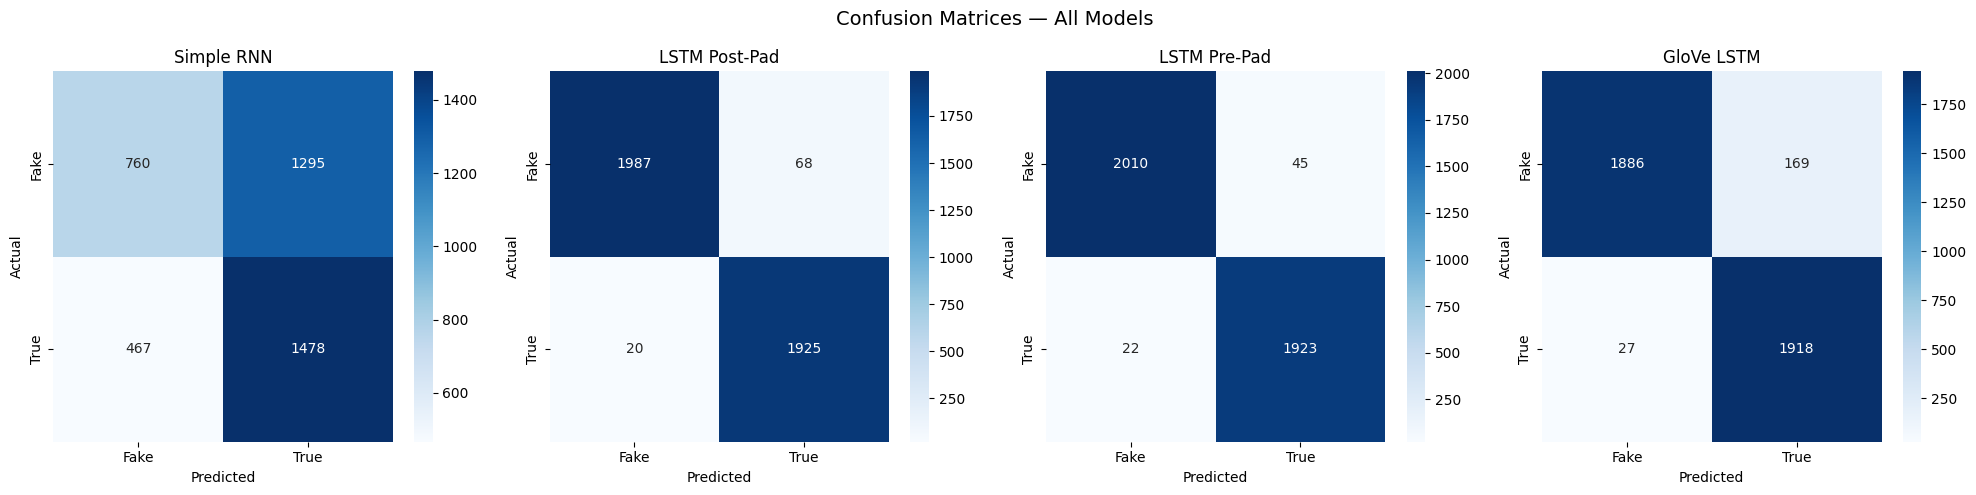

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
models_names = ['Simple RNN', 'LSTM Post-Pad', 'LSTM Pre-Pad', 'GloVe LSTM']
preds = [y_pred_rnn, y_pred_lstm, y_pred_lstm_pre, y_pred_w2v]

for ax, name, pred in zip(axes, models_names, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','True'],
                yticklabels=['Fake','True'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

Plot Precision Recall and F1 Score Comparison

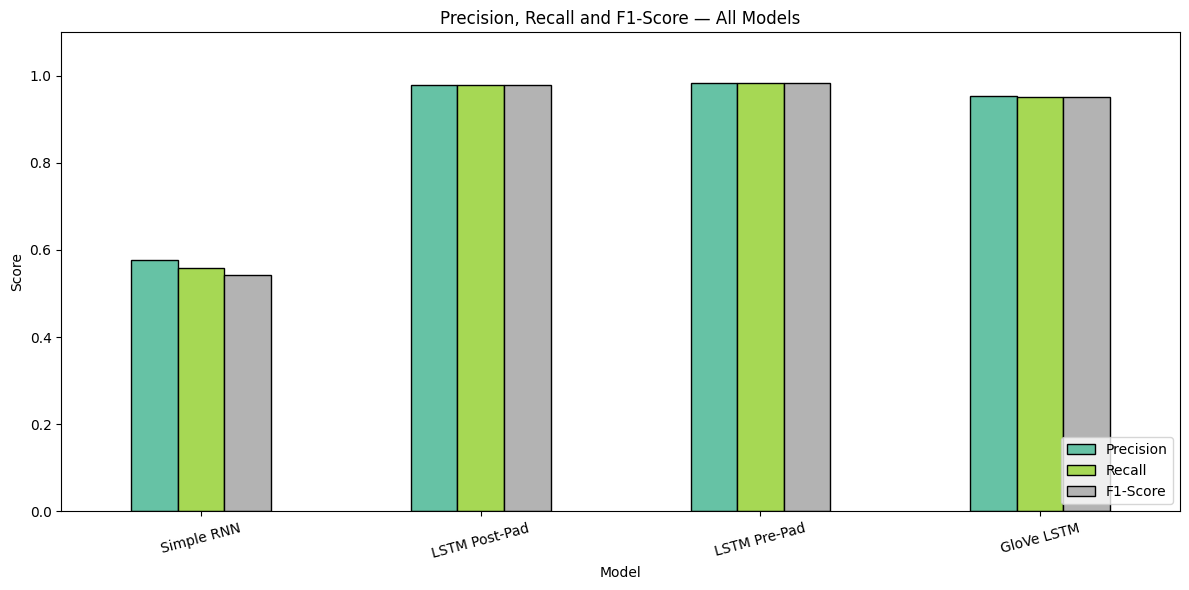

In [98]:
from sklearn.metrics import classification_report

r_rnn = classification_report(y_test, y_pred_rnn, target_names=['Fake','True'], output_dict=True)
r_lstm = classification_report(y_test, y_pred_lstm, target_names=['Fake','True'], output_dict=True)
r_lstm_pre = classification_report(y_test, y_pred_lstm_pre, target_names=['Fake','True'], output_dict=True)
r_w2v = classification_report(y_test, y_pred_w2v, target_names=['Fake','True'], output_dict=True)

metrics_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM Post-Pad', 'LSTM Pre-Pad', 'GloVe LSTM'],
    'Precision': [r_rnn['weighted avg']['precision'], r_lstm['weighted avg']['precision'],
                  r_lstm_pre['weighted avg']['precision'], r_w2v['weighted avg']['precision']],
    'Recall':    [r_rnn['weighted avg']['recall'], r_lstm['weighted avg']['recall'],
                  r_lstm_pre['weighted avg']['recall'], r_w2v['weighted avg']['recall']],
    'F1-Score':  [r_rnn['weighted avg']['f1-score'], r_lstm['weighted avg']['f1-score'],
                  r_lstm_pre['weighted avg']['f1-score'], r_w2v['weighted avg']['f1-score']],
})

metrics_df.set_index('Model')[['Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black'
)
plt.title('Precision, Recall and F1-Score — All Models')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Plot Sequence Length Distribution

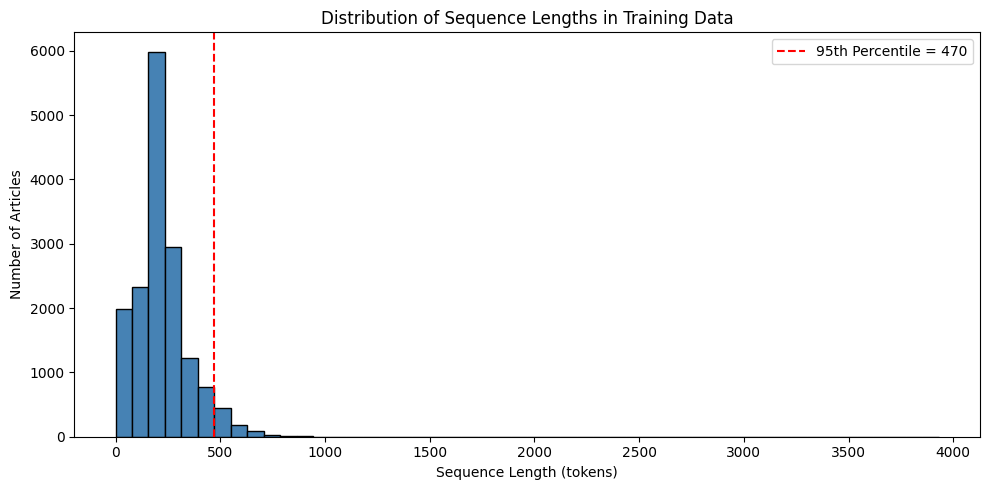

In [99]:
plt.figure(figsize=(10, 5))
plt.hist(sequence_lengths, bins=50, color='steelblue', edgecolor='black')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th Percentile = {max_len}')
plt.title('Distribution of Sequence Lengths in Training Data')
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Number of Articles')
plt.legend()
plt.tight_layout()
plt.show()

 Define News Prediction Function

In [100]:
def predict_news(text):
    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='pre',
        truncating='pre'
    )

    probability = model_lstm_pre.predict(padded)[0][0]

    if probability >= 0.5:
        prediction = "True News"
    else:
        prediction = "Fake News"

    print("Original Text:", text)
    print("Cleaned Text:", cleaned)
    print("Prediction:", prediction)
    print("Confidence:", probability)

Test Prediction on Fake News Example

In [101]:
predict_news(
    "NASA confirms new discovery about water on Mars after successful space mission."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Original Text: NASA confirms new discovery about water on Mars after successful space mission.
Cleaned Text: nasa confirms new discovery water mar successful space mission
Prediction: Fake News
Confidence: 0.42870075


Test Prediction on True News Example

In [102]:
predict_news(
    "Reuters reports that the government approved a new international climate agreement."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Original Text: Reuters reports that the government approved a new international climate agreement.
Cleaned Text: reuters report government approved new international climate agreement
Prediction: True News
Confidence: 0.90438145


Identify All Misclassified Samples

In [103]:
y_pred_probs = model_lstm_pre.predict(X_test_pad_pre)

y_pred_labels = (y_pred_probs > 0.5).astype(int).flatten()

error_df = pd.DataFrame({
    'Text': X_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred_labels
})

errors = error_df[
    error_df['Actual'] != error_df['Predicted']
]

print("Total Incorrect Predictions:", len(errors))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Total Incorrect Predictions: 67


 Display Raw Error Examples

In [104]:
errors.head(5)

,Text,Actual,Predicted
85,portrait punk hillary set two security dog art...,0,1
127,reuters wall street firm set better u presiden...,1,0
163,history show must tolerate nuclear weapon nort...,0,1
173,another case love trump hate lol hate unhinged...,0,1
202,senate minority leader chuck schumer think lik...,0,1


Format Error Analysis with Readable Labels

In [105]:
errors['Actual_Label'] = errors['Actual'].map({
    0: 'Fake',
    1: 'True'
})

errors['Predicted_Label'] = errors['Predicted'].map({
    0: 'Fake',
    1: 'True'
})

errors[
    ['Text', 'Actual_Label', 'Predicted_Label']
].head(5)

/tmp/ipykernel_3621/2301676934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual_Label'] = errors['Actual'].map({
/tmp/ipykernel_3621/2301676934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted_Label'] = errors['Predicted'].map({


,Text,Actual_Label,Predicted_Label
85,portrait punk hillary set two security dog art...,Fake,True
127,reuters wall street firm set better u presiden...,True,Fake
163,history show must tolerate nuclear weapon nort...,Fake,True
173,another case love trump hate lol hate unhinged...,Fake,True
202,senate minority leader chuck schumer think lik...,Fake,True


 Install Gradio Library

In [106]:
!pip install gradio

Build and Launch Real-Time Gradio Interface

In [107]:
import gradio as gr

def detect_fake_news(text):
    if not text.strip():
        return "Please enter some news text."

    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='pre', truncating='pre')
    probability = model_lstm_pre.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        label = "TRUE NEWS"
        confidence = probability * 100
    else:
        label = "FAKE NEWS"
        confidence = (1 - probability) * 100

    return f"Prediction: {label}\nConfidence: {confidence:.2f}%"


interface = gr.Interface(
    fn=detect_fake_news,

    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter a news article or headline...",
        label="News Text"
    ),

    outputs=gr.Textbox(
        label="Result",
        lines=3
    ),

    title="Fake News Detection",
    description="Enter any news article or headline to check whether it is real or fake.",

    examples=[
        ["Reuters reports that the government approved a new climate agreement."],
        ["Scientists prove chocolate makes you live 100 years longer."],
        ["The Federal Reserve announced a 0.25% interest rate increase."],
    ],

    theme=gr.themes.Default(),
    allow_flagging="never"
)

interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47aa76c9eb9c36297b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
